In [1]:
# [CELL 1]: RESEARCH DEPENDENCIES
!pip install -q kaggle h5py matplotlib seaborn scikit-learn

In [2]:
import os
import h5py
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files, drive
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks

# Mount Drive for persistent CV-ANN weight storage
drive.mount('/content/drive')
RES_DIR = "/content/drive/MyDrive/Mod_Class_Research"
CP_DIR = os.path.join(RES_DIR, "checkpoints")
os.makedirs(CP_DIR, exist_ok=True)

# Define master knowledge path
MODEL_WEIGHTS_PATH = os.path.join(CP_DIR, "cv_ann_modulation_chunk_8_dummy.keras")
print(f"Namespace established. Master weights location: {MODEL_WEIGHTS_PATH}")

Mounted at /content/drive
Namespace established. Master weights location: /content/drive/MyDrive/Mod_Class_Research/checkpoints/cv_ann_modulation_chunk_8_dummy.keras


In [3]:
# [CELL 3]: KAGGLE API & HDF5 CHUNK EXTRACTION

if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fn in uploaded.keys(): os.rename(fn, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 600)


!kaggle datasets download -d elpantherd/am-dsb-wc-am-dsb-sc
!unzip -q am-dsb-wc-am-dsb-sc.zip -d ./chunk_data
!rm am-dsb-wc-am-dsb-sc.zip

import os
h5_path = './chunk_data/chunk_8.h5'
if os.path.exists(h5_path):
    print(f"HDF5 Volume Verified: {h5_path}")
else:
    # Diagnostic to check if the file name inside the zip is different
    print("Listing extracted files:", os.listdir('./chunk_data'))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/elpantherd/am-dsb-wc-am-dsb-sc
License(s): unknown
100% 1.50G/1.51G [00:17<00:00, 127MB/s]
100% 1.51G/1.51G [00:17<00:00, 90.5MB/s]
HDF5 Volume Verified: ./chunk_data/chunk_8.h5


In [4]:
import h5py
with h5py.File(h5_path, 'r') as f:
    print("Internal HDF5 Keys Found:", list(f.keys()))


Internal HDF5 Keys Found: ['X_test', 'X_train', 'Y_test', 'Y_train', 'Z_test', 'Z_train']


In [5]:
import h5py
import pandas as pd
import numpy as np
from IPython.display import display

def inspect_dataset(file_path):
    classes = ['OOK','4ASK','8ASK','BPSK','QPSK','8PSK','16PSK','32PSK',
               '16APSK','32APSK','64APSK','128APSK','16QAM','32QAM',
               '64QAM','128QAM','256QAM','AM-SSB-WC','AM-SSB-SC',
               'AM-DSB-WC','AM-DSB-SC','FM','GMSK','OQPSK']

    with h5py.File(file_path, 'r') as f:
        print(f"File: {file_path}")
        print("-" * 30)
        for k in f.keys():
            print(f"Key: {k:10} | Shape: {str(f[k].shape):15} | Dtype: {f[k].dtype}")

        x_key = next((k for k in ['X_train', 'X_test', 'X'] if k in f.keys()), None)
        y_key = next((k for k in ['Y_train', 'Y_test', 'Y'] if k in f.keys()), None)
        z_key = next((k for k in ['Z_train', 'Z_test', 'Z'] if k in f.keys()), None)

        if all([x_key, y_key, z_key]):
            x_sub = f[x_key][:10]
            y_sub = f[y_key][:10]
            z_sub = f[z_key][:10]

            df = pd.DataFrame({
                'Modulation': [classes[np.argmax(y)] for y in y_sub],
                'SNR (dB)': z_sub.flatten(),
                'Data Shape': [x.shape for x in x_sub],
                'I/Q Sample': [f"{x[0,0]:.4f}, {x[0,1]:.4f}..." for x in x_sub]
            })
            print("\nFirst 10 Rows:")
            display(df)

if 'h5_path' in locals():
    inspect_dataset(h5_path)

File: ./chunk_data/chunk_8.h5
------------------------------
Key: X_test     | Shape: (42599, 1024, 2) | Dtype: float32
Key: X_train    | Shape: (170393, 1024, 2) | Dtype: float32
Key: Y_test     | Shape: (42599, 24)     | Dtype: int64
Key: Y_train    | Shape: (170393, 24)    | Dtype: int64
Key: Z_test     | Shape: (42599, 1)      | Dtype: int64
Key: Z_train    | Shape: (170393, 1)     | Dtype: int64

First 10 Rows:


,Modulation,SNR (dB),Data Shape,I/Q Sample
0,AM-DSB-SC,-12,"(1024, 2)","0.4520, 0.9976..."
1,AM-DSB-WC,22,"(1024, 2)","-0.1110, 0.2742..."
2,AM-DSB-SC,10,"(1024, 2)","0.6338, 0.5384..."
3,AM-DSB-SC,6,"(1024, 2)","-0.3820, -0.0567..."
4,AM-DSB-WC,-8,"(1024, 2)","0.4806, 0.4436..."
5,AM-DSB-WC,26,"(1024, 2)","-0.1205, 1.0059..."
6,AM-DSB-SC,-2,"(1024, 2)","-0.5087, -0.9725..."
7,AM-DSB-WC,26,"(1024, 2)","-1.2395, 0.4852..."
8,AM-DSB-WC,30,"(1024, 2)","-0.8029, 0.0842..."
9,AM-DSB-SC,-8,"(1024, 2)","0.5988, -0.9902..."


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# 1. LOCAL FEATURE EXTRACTORS (Retained for I/Q geometry)
class ComplexConv1D(layers.Layer):
    def __init__(self, filters, kernel_size, dilation_rate=1, **kwargs):
        super(ComplexConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate

    def build(self, input_shape):
        input_dim = input_shape[-1] // 2
        self.w_real = self.add_weight(shape=(self.kernel_size, input_dim, self.filters), initializer='glorot_uniform', name='w_real')
        self.w_imag = self.add_weight(shape=(self.kernel_size, input_dim, self.filters), initializer='glorot_uniform', name='w_imag')
        self.b_real = self.add_weight(shape=(self.filters,), initializer='zeros', name='b_real')
        self.b_imag = self.add_weight(shape=(self.filters,), initializer='zeros', name='b_imag')

    def call(self, inputs):
        I, Q = inputs[..., :inputs.shape[-1]//2], inputs[..., inputs.shape[-1]//2:]
        r = tf.nn.conv1d(I, self.w_real, 1, 'SAME', dilations=self.dilation_rate) - tf.nn.conv1d(Q, self.w_imag, 1, 'SAME', dilations=self.dilation_rate)
        i = tf.nn.conv1d(Q, self.w_real, 1, 'SAME', dilations=self.dilation_rate) + tf.nn.conv1d(I, self.w_imag, 1, 'SAME', dilations=self.dilation_rate)
        return tf.concat([tf.nn.bias_add(r, self.b_real), tf.nn.bias_add(i, self.b_imag)], axis=-1)

class ModReLU(layers.Layer):
    def build(self, input_shape):
        self.b = self.add_weight(shape=(input_shape[-1]//2,), initializer='zeros', name='bias')

    def call(self, inputs):
        c = inputs.shape[-1]//2
        I, Q = inputs[..., :c], inputs[..., c:]
        mag = tf.sqrt(tf.square(I) + tf.square(Q) + 1e-8)
        scale = tf.nn.relu(mag + self.b) / mag
        return tf.concat([I * scale, Q * scale], axis=-1)

# 2. NEW: TEMPORAL ATTENTION MECHANISM
class TemporalAttention(layers.Layer):
    """
    Learns to dynamically mask out 'silent' frames in the audio sequence
    and amplify the active carrier/sideband frames.
    """
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, time_steps, features)
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(1,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, x):
        # Calculate alignment scores
        scores = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)

        # Convert to probability weights across the time dimension
        attention_weights = tf.nn.softmax(scores, axis=1)

        # Multiply sequence by weights and sum to create a single context vector
        context_vector = x * attention_weights
        return tf.reduce_sum(context_vector, axis=1)

# 3. ASSEMBLE CRNN
def build_attention_crnn(input_shape=(1024, 2), num_classes=24):
    inputs = layers.Input(shape=input_shape)

    # --- FRONTEND: SPATIAL FEATURE EXTRACTION ---
    x = ComplexConv1D(64, 7)(inputs)
    x = ModReLU()(x)
    x = layers.AveragePooling1D(pool_size=4)(x) # Reduce sequence length from 1024 to 256 for LSTM efficiency

    x = ComplexConv1D(128, 5)(x)
    x = ModReLU()(x)
    x = layers.AveragePooling1D(pool_size=4)(x) # Sequence length is now 64 time steps

    # --- MIDDLE: SEQUENCE MODELING ---
    # The Bi-LSTM tracks the temporal evolution of the AM envelope
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)

    # --- BOTTLENECK: TEMPORAL ATTENTION ---
    # Drops the dead air, isolates the active voice transmission
    x = TemporalAttention()(x)

    # --- BACKEND: CLASSIFICATION ---
    z = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    z = layers.BatchNormalization()(z)
    z = layers.Activation('relu')(z)
    z = layers.Dropout(0.4)(z)

    outputs = layers.Dense(num_classes, activation='softmax')(z)
    return models.Model(inputs, outputs)

# Initialize
model = build_attention_crnn(num_classes=24)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Attention-Guided CRNN Initialized. Sequence modeling active.")

Attention-Guided CRNN Initialized. Sequence modeling active.


In [ ]:
import gc
import h5py
import tensorflow as tf
from tensorflow.keras import callbacks

tf.keras.backend.clear_session()
gc.collect()

class ResearchProgress(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch+1:03d} | Loss: {logs['loss']:.4f} | Acc: {logs['accuracy']:.4f} | Val_Acc: {logs['val_accuracy']:.4f}")

with h5py.File(h5_path, 'r') as f:
    x_train = f['X_train'][:]
    y_train = f['Y_train'][:]

    if 'X_test' in f.keys():
        x_val = f['X_test'][:]
        y_val = f['Y_test'][:]
        z_val = f['Z_test'][:]
    else:
        from sklearn.model_selection import train_test_split
        z_all = f['Z_train'][:]
        x_train, x_val, y_train, y_val, _, z_val = train_test_split(x_train, y_train, z_all, test_size=0.1)

print(f"Training on {x_train.shape[0]} samples for 200 Epochs...")

lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6, verbose=0)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
model_ckpt = callbacks.ModelCheckpoint(MODEL_WEIGHTS_PATH, save_best_only=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=256,
    epochs=200,
    callbacks=[ResearchProgress(), model_ckpt, lr_scheduler, early_stopping],
    verbose=0
)

print(f"Weights saved to {MODEL_WEIGHTS_PATH}")

Training on 170393 samples for 200 Epochs...
Epoch 001 | Loss: 0.7052 | Acc: 0.5013 | Val_Acc: 0.5002
Epoch 002 | Loss: 0.7007 | Acc: 0.5010 | Val_Acc: 0.4996
Epoch 003 | Loss: 0.6984 | Acc: 0.4993 | Val_Acc: 0.5012
Epoch 004 | Loss: 0.6967 | Acc: 0.4996 | Val_Acc: 0.4998
Epoch 005 | Loss: 0.6956 | Acc: 0.5013 | Val_Acc: 0.5000
Epoch 006 | Loss: 0.6952 | Acc: 0.5008 | Val_Acc: 0.5002
Epoch 007 | Loss: 0.6952 | Acc: 0.4993 | Val_Acc: 0.5000
Epoch 008 | Loss: 0.6950 | Acc: 0.5018 | Val_Acc: 0.5000
Epoch 009 | Loss: 0.6949 | Acc: 0.5013 | Val_Acc: 0.5014
Epoch 010 | Loss: 0.6950 | Acc: 0.5004 | Val_Acc: 0.4988
Epoch 011 | Loss: 0.6946 | Acc: 0.5006 | Val_Acc: 0.4993
Epoch 012 | Loss: 0.6947 | Acc: 0.5010 | Val_Acc: 0.4996
Epoch 013 | Loss: 0.6947 | Acc: 0.5013 | Val_Acc: 0.4997
Epoch 014 | Loss: 0.6947 | Acc: 0.4999 | Val_Acc: 0.4987
Epoch 015 | Loss: 0.6938 | Acc: 0.5016 | Val_Acc: 0.4956
Epoch 016 | Loss: 0.6937 | Acc: 0.4999 | Val_Acc: 0.4980
Epoch 017 | Loss: 0.6937 | Acc: 0.5005 | Va

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('Complex Convergence: Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='green')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='red', linestyle='--')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Awaiting model weights upload (.keras or .h5):


Saving cv_ann_modulation_chunk_8.keras to cv_ann_modulation_chunk_8.keras
Restoring model state from: cv_ann_modulation_chunk_8.keras
Initializing validation data pipeline...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Executing model inference...

EVALUATION METRICS
Aggregate Accuracy (All SNRs):  76.63%
High-SNR Accuracy (>= +4 dB):   94.16%
Low-SNR Accuracy  (<=  0 dB):   53.64%


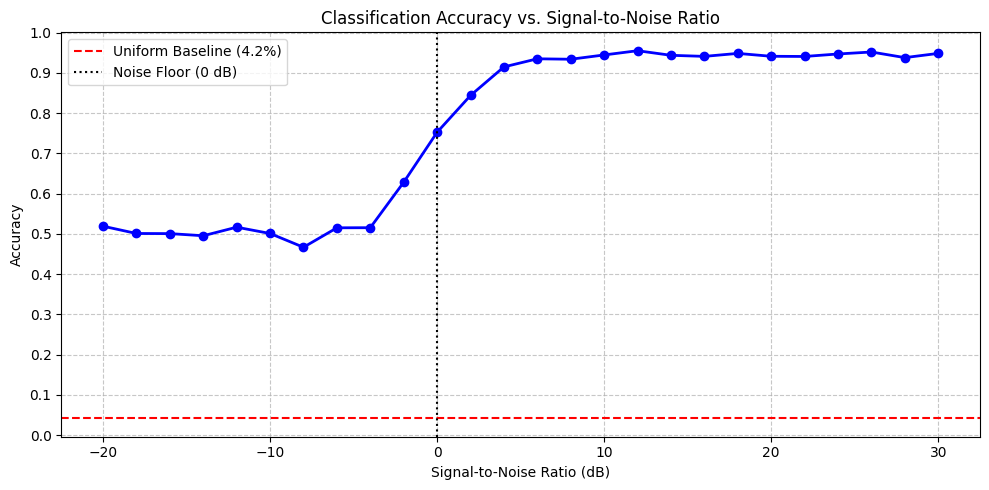


PHASE INVARIANCE ANALYSIS (ALL ACTIVE BANDS)
Target: AM-DSB-WC  | Max Divergence: 0.000866845 | Status: PASSED
Target: AM-DSB-SC  | Max Divergence: 0.167113543 | Status: FAILED


In [7]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

print("Awaiting model weights upload (.keras or .h5):")
uploaded = files.upload()
weights_file = list(uploaded.keys())[0]

print(f"Restoring model state from: {weights_file}")
model.load_weights(weights_file)

print("Initializing validation data pipeline...")
data_path = h5_path if 'h5_path' in locals() else './chunk_data/chunk_1.h5'
with h5py.File(data_path, 'r') as f:
    if 'X_test' in f.keys():
        x_val, y_val, z_val = f['X_test'][:], f['Y_test'][:], f['Z_test'][:]
    else:
        x_train, y_train, z_train = f['X_train'][:], f['Y_train'][:], f['Z_train'][:]
        _, x_val, _, y_val, _, z_val = train_test_split(x_train, y_train, z_train, test_size=0.1, random_state=42)

print("Executing model inference...")
preds = model.predict(x_val, batch_size=1024, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_val, axis=1)
z_flat = z_val.flatten()

high_snr_mask = z_flat >= 4
low_snr_mask = z_flat <= 0

acc_overall = np.mean(y_pred == y_true)
acc_high = np.mean(y_pred[high_snr_mask] == y_true[high_snr_mask]) if np.any(high_snr_mask) else 0
acc_low = np.mean(y_pred[low_snr_mask] == y_true[low_snr_mask]) if np.any(low_snr_mask) else 0

print("\n" + "="*65)
print("EVALUATION METRICS")
print("="*65)
print(f"Aggregate Accuracy (All SNRs):  {acc_overall * 100:.2f}%")
print(f"High-SNR Accuracy (>= +4 dB):   {acc_high * 100:.2f}%")
print(f"Low-SNR Accuracy  (<=  0 dB):   {acc_low * 100:.2f}%")
print("="*65)

# Generate Waterfall Curve
snrs = np.sort(np.unique(z_flat))
acc_scores = [np.mean(y_pred[z_flat == snr] == y_true[z_flat == snr]) for snr in snrs]

# Dynamically calculate baseline based on the number of classes in the current chunk
active_classes_count = y_val.shape[1]
uniform_baseline = 1.0 / active_classes_count

plt.figure(figsize=(10, 5))
plt.plot(snrs, acc_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.axhline(y=uniform_baseline, color='r', linestyle='--', label=f'Uniform Baseline ({uniform_baseline*100:.1f}%)')
plt.axvline(x=0, color='k', linestyle=':', label='Noise Floor (0 dB)')
plt.title('Classification Accuracy vs. Signal-to-Noise Ratio')
plt.xlabel('Signal-to-Noise Ratio (dB)')
plt.ylabel('Accuracy')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# COMPREHENSIVE PHASE INVARIANCE TEST FOR ALL ACTIVE BANDS
# ---------------------------------------------------------
print("\n" + "="*65)
print("PHASE INVARIANCE ANALYSIS (ALL ACTIVE BANDS)")
print("="*65)

classes = ['OOK','4ASK','8ASK','BPSK','QPSK','8PSK','16PSK','32PSK',
           '16APSK','32APSK','64APSK','128APSK','16QAM','32QAM',
           '64QAM','128QAM','256QAM','AM-SSB-WC','AM-SSB-SC',
           'AM-DSB-WC','AM-DSB-SC','FM','GMSK','OQPSK']


active_idx = np.unique(np.argmax(y_val, axis=1))

for cls_idx in active_idx:
    # Isolate the first sample belonging to this specific class
    sample_idx = np.where(np.argmax(y_val, axis=1) == cls_idx)[0][0]
    x_sample = x_val[sample_idx:sample_idx+1]

    # Base prediction
    pred_orig = model.predict(x_sample, verbose=0)

    # Introduce arbitrary 45-degree phase rotation
    theta = np.pi / 4
    I, Q = x_sample[0,:,0], x_sample[0,:,1]
    Z_complex = (I + 1j*Q) * np.exp(1j * theta)
    x_rot = np.stack([np.real(Z_complex), np.imag(Z_complex)], axis=1)[np.newaxis, ...]

    # Rotated prediction
    pred_rot = model.predict(x_rot, verbose=0)

    # Compute divergence across the probability distribution
    diff = np.max(np.abs(pred_orig - pred_rot))

    # Evaluate against standard GPU float32 precision limits
    mod_name = classes[cls_idx]
    status = "PASSED" if diff < 1e-3 else "FAILED"

    print(f"Target: {mod_name:10} | Max Divergence: {diff:.9f} | Status: {status}")

print("="*65)